# 📊 Trabalho Final: Análise de Fatores Salariais em Empresa Multinacional

**Aluno:** Fabio Kishino  
**Data:** Setembro 2025

## 🎯 Tema de Estudo

O problema central deste trabalho é compreender quais fatores influenciam o salário dos profissionais em uma empresa multinacional. Em particular, busca-se investigar de que forma variáveis como o regime de trabalho (on-site vs. remoto), o tempo de experiência profissional e o departamento influenciam na remuneração. <br>

---

### 📈 Fonte de Dados

A fonte utilizada é o dataset público **"HR Data MNC"**, disponibilizado no portal [Kaggle](https://www.kaggle.com/datasets/rohitgrewal/hr-data-mnc).

A base contém informações abrangentes de funcionários, incluindo variáveis como:
- Salário
- Anos de experiência
- Localização geográfica
- Regime de trabalho (on-site ou remoto)
- Departamento de atuação

---
## 🔍 Objetivos da Análise

O foco da análise é **explorar a relação entre características profissionais com a variável salário**. Especificamente, pretende-se:

### Objetivos Específicos

1. **📍 Regime de Trabalho**  
   Comparar o impacto do regime de trabalho on-site versus remoto na remuneração

2. **⏱️ Experiência Profissional**  
   Analisar como o tempo de experiência influencia o salário

3. **🏢 Salário do Departamento de TI**  
   Avaliar como os cargos do departamento de TI se relaciona com os níveis de remuneração

> **Resultado Esperado:** Esses pontos permitirão identificar padrões salariais relevantes e fornecer uma visão abrangente dos fatores determinantes para a remuneração.

---

## 🛠️ Metodologia

Para alcançar os objetivos, serão aplicadas **técnicas de mineração de dados** contemplando as seguintes etapas:

1. 🔧 Pré-processamento e Transformação
- Tratamento de valores ausentes
- Normalização de variáveis
- Conversão de unidades monetárias

2. 📊 Análise Exploratória de Dados (EDA)
- Estatísticas descritivas
- Visualizações através de gráficos
- Análise de correlações entre variáveis

3. 🤖 Técnicas de Regressão
- **Regressão Linear Múltipla (OLS, Lasso e Ridge):** para mensurar a influência das variáveis (Department, Job_Title, Performance_Rating, Experience_Years) no Salário 
   - Utilizar GridSearchCV para obter os melhores valores de alpha.

In [ ]:
# Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
df = pd.read_csv('../../data-sets/HR_Data_MNC_Data Science Lovers.csv')
df

,Unnamed: 0,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082
...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648
1999996,1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109
1999997,1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085
1999998,1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727


## **Preprocessamento**

In [3]:
# Querying only Active employees and creating a copy to avoid warnings
df = df.query("Status == 'Active'").copy()

# Dropping unnecessary columns
df = df.drop(columns=['Unnamed: 0','Employee_ID', 'Full_Name'])

In [4]:
# Verificando se existem valores nulos
df.isnull().any()


Department            False
Job_Title             False
Hire_Date             False
Location              False
Performance_Rating    False
Experience_Years      False
Status                False
Work_Mode             False
Salary_INR            False
dtype: bool

In [5]:
df.columns

Index(['Department', 'Job_Title', 'Hire_Date', 'Location',
       'Performance_Rating', 'Experience_Years', 'Status', 'Work_Mode',
       'Salary_INR'],
      dtype='object')

In [6]:
# Conversão de moeda
df['Salary_INR'] = df['Salary_INR'].astype('float64')

# Média anual da taxa de câmbio INR para BRL em 2025: 0.0656
df.loc[:, 'Salary_BRL_Mensal'] = round(((df['Salary_INR'] * 0.0656)/12), 2)
df

,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR,Salary_BRL_Mensal
1,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686.0,4634.02
2,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084.0,7817.79
3,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689.0,5415.77
4,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082.0,2925.11
5,Operations,Logistics Coordinator,2021-02-23,"Zimmermanstad, Bulgaria",5,4,Active,On-site,641393.0,3506.28
...,...,...,...,...,...,...,...,...,...,...
1999994,Sales,Sales Director,2012-02-19,"Simpsonberg, Uganda",1,13,Active,Remote,450459.0,2462.51
1999995,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648.0,3595.14
1999996,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109.0,5631.26
1999997,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085.0,7178.20


In [7]:
df.drop(columns=['Salary_INR'], inplace=True)
df

,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_BRL_Mensal
1,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,4634.02
2,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,7817.79
3,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,5415.77
4,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,2925.11
5,Operations,Logistics Coordinator,2021-02-23,"Zimmermanstad, Bulgaria",5,4,Active,On-site,3506.28
...,...,...,...,...,...,...,...,...,...
1999994,Sales,Sales Director,2012-02-19,"Simpsonberg, Uganda",1,13,Active,Remote,2462.51
1999995,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,3595.14
1999996,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,5631.26
1999997,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,7178.20


In [8]:
# Criação da coluna País e Cidade
# df['Country'] = df['Location'].apply(lambda x: x.split(',')[-1].strip())
# df['City'] = df['Location'].apply(lambda x: x.split(',')[0].strip())
# df = df.drop(columns=['Location'])

# Reordenando as colunas
# df = df[['Country','City', 'Department', 'Job_Title', 'Hire_Date', 'Performance_Rating','Experience_Years', 'Status', 'Work_Mode', 'Salary_BRL']]


In [9]:
# Calculo da média salarial por modo de trabalho
salary_by_work_mode = df.groupby('Work_Mode')['Salary_BRL_Mensal'].mean().reset_index()
print("Média Salarial Por modo de trabalho (Remoto e Presencial):")
print(salary_by_work_mode)

Média Salarial Por modo de trabalho (Remoto e Presencial):
  Work_Mode  Salary_BRL_Mensal
0   On-site        4902.568186
1    Remote        4903.687648


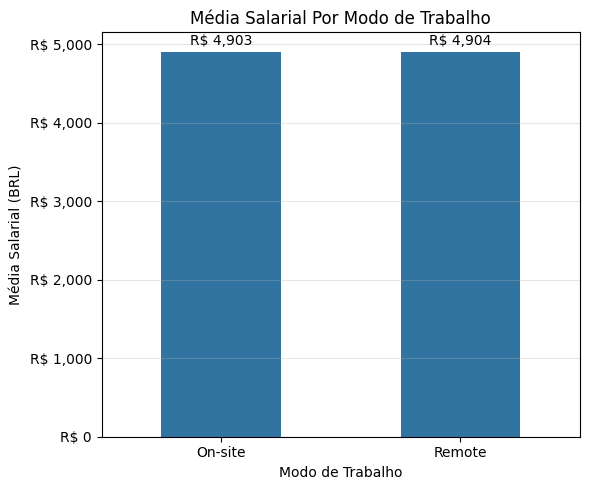

In [10]:
# Gráfico
plt.figure(figsize=(6, 5))
ax = sns.barplot(data=salary_by_work_mode, x='Work_Mode', y='Salary_BRL_Mensal', width=0.5)

# Adicionar valores nas barras
for i, v in enumerate(salary_by_work_mode['Salary_BRL_Mensal']):
    ax.text(i, v + (v * 0.01), f'R$ {v:,.0f}', ha='center', va='bottom')

plt.title('Média Salarial Por Modo de Trabalho')
plt.xlabel('Modo de Trabalho')
plt.ylabel('Média Salarial (BRL)')
plt.grid(axis='y', alpha=0.3)

# Format y-axis to show currency
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'R$ {x:,.0f}'))

plt.tight_layout()
plt.show()

### **Gráfico 01**

De modo geral, o modo de trabalho não apresentou diferenças estatisticamente significativas nos salários. No entanto, seria necessário aprofundar a análise para confirmar esse resultado com maior precisão.

### **Análise por setor**

Objetivo: analisar a diferença entre as médias salariais de cada setor e com base no modo de trabalho

In [ ]:
# Analisar Diferenças Salariais dos setores (Remoto e Presencial)
print(df['Department'].unique())

for department in df['Department'].unique():
  df_dp = df[df['Department'] == department]

  # Calcular a média salarial por modo de trabalho
  salary_by_work_mode_dp = df_dp.groupby('Work_Mode')['Salary_BRL_Mensal'].mean().reset_index()
  print(f"Média Salarial Por modo de trabalho (Remoto e Presencial) - {department}:")
  print(salary_by_work_mode_dp)

['Marketing' 'HR' 'IT' 'Operations' 'Finance' 'Sales' 'R&D']
Média Salarial Por modo de trabalho (Remoto e Presencial) - Marketing:
  Work_Mode  Salary_BRL_Mensal
0   On-site        4206.048427
1    Remote        4205.882495
Média Salarial Por modo de trabalho (Remoto e Presencial) - HR:
  Work_Mode  Salary_BRL_Mensal
0   On-site        4068.014982
1    Remote        4067.668010
Média Salarial Por modo de trabalho (Remoto e Presencial) - IT:
  Work_Mode  Salary_BRL_Mensal
0   On-site        6173.650541
1    Remote        6175.890691
Média Salarial Por modo de trabalho (Remoto e Presencial) - Operations:
  Work_Mode  Salary_BRL_Mensal
0   On-site        4131.557181
1    Remote        4122.121739
Média Salarial Por modo de trabalho (Remoto e Presencial) - Finance:
  Work_Mode  Salary_BRL_Mensal
0   On-site        5135.027483
1    Remote        5156.497114
Média Salarial Por modo de trabalho (Remoto e Presencial) - Sales:
  Work_Mode  Salary_BRL_Mensal
0   On-site        4338.695034
1    

- Não foram identificadas diferenças significativas na média salarial entre os setores, mesmo quando comparados com o modo de trabalho adotado.

In [12]:
# Correlação entre variáveis numéricas
df[['Performance_Rating', 'Experience_Years', 'Salary_BRL_Mensal']].corr()

,Performance_Rating,Experience_Years,Salary_BRL_Mensal
Performance_Rating,1.000000,-0.000825,-0.000011
Experience_Years,-0.000825,1.000000,0.000478
Salary_BRL_Mensal,-0.000011,0.000478,1.000000


- Não foi encontrada correlação linear relevante entre as variáveis Performance_Rating, Experience_Years e Salary_BRL_Mensal.

## **Regressão Múltipla (Apenas para o Departamento de TI)**

### **Separação do dataset**

In [13]:
df = df.query("Department == 'IT'").copy()

In [15]:
df.columns

Index(['Department', 'Job_Title', 'Hire_Date', 'Location',
       'Performance_Rating', 'Experience_Years', 'Status', 'Work_Mode',
       'Salary_BRL_Mensal'],
      dtype='object')

In [16]:
df

,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_BRL_Mensal
3,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,5415.77
9,IT,Software Engineer,2015-10-08,"Brownport, Yemen",4,9,Active,Remote,8435.62
18,IT,DevOps Engineer,2025-04-05,"Matthewsville, Ghana",2,0,Active,On-site,3450.96
21,IT,DevOps Engineer,2015-07-07,"Houstonland, Qatar",2,10,Active,On-site,3956.88
24,IT,IT Manager,2021-07-31,"Tammyview, Barbados",2,4,Active,Remote,11770.27
...,...,...,...,...,...,...,...,...,...
1999967,IT,CTO,2022-12-09,"East Shelby, Bulgaria",5,2,Active,On-site,4664.76
1999975,IT,Software Engineer,2017-12-27,"Peterberg, Denmark",4,7,Active,On-site,5955.99
1999980,IT,Software Engineer,2022-01-23,"East Gary, Fiji",3,3,Active,On-site,7455.38
1999992,IT,Data Analyst,2021-10-17,"Gonzalezstad, Korea",1,3,Active,On-site,5236.08


### **Análise da variação salarial com base nos anos de experiência**

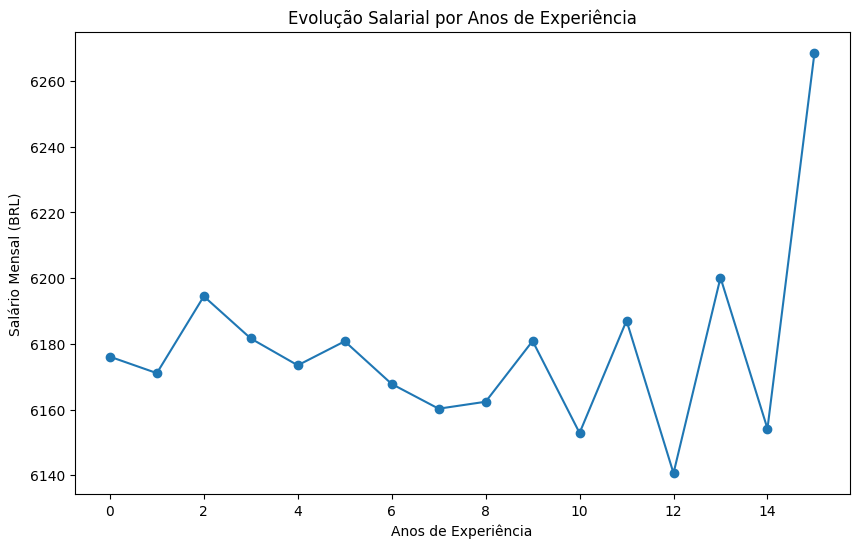

In [31]:
data = df.groupby('Experience_Years')['Salary_BRL_Mensal'].mean()

# Plot da evolução salarial por anos de experiência
plt.figure(figsize=(10, 6))
plt.plot(data, marker='o')
plt.title('Evolução Salarial por Anos de Experiência')
plt.xlabel('Anos de Experiência')
plt.ylabel('Salário Mensal (BRL)')
plt.show()


- A análise não permite concluir que salários mais altos estejam associados a um maior número de anos de experiência.

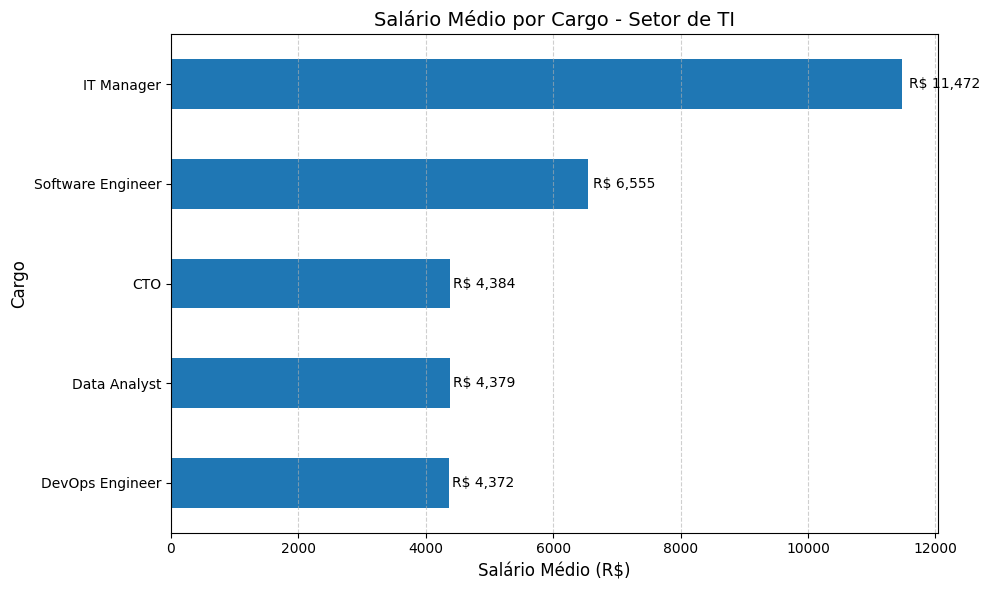

In [17]:
# Gráfico para mostrar o salário médio por cargo no setor de TI
salary_means = df.groupby('Job_Title')['Salary_BRL_Mensal'].mean().sort_values()

plt.figure(figsize=(10, 6))
salary_means.plot(kind='barh')
plt.title('Salário Médio por Cargo - Setor de TI', fontsize=14)
plt.xlabel('Salário Médio (R$)', fontsize=12)
plt.ylabel('Cargo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, v in enumerate(salary_means):
    plt.text(v + (v * 0.01), i, f'R$ {v:,.0f}', va='center')

plt.tight_layout()
plt.show()

### **Gráfico 02**

- O gráfico de médias salariais revela que IT Manager e Software Engineer são os cargos com maior remuneração média, seguidos pelo CTO. Esse resultado é inesperado, uma vez que o cargo de CTO costuma estar no topo da hierarquia organizacional e, portanto, seria esperado que apresentasse o maior salário.

### **Separação do dataset em treino e teste**

- O dataset foi filtrado para apenas o departamento de TI e dividido em teste (20%) e treino (80%).

In [18]:
# Separação do dataset para teste e treino
from sklearn.model_selection import train_test_split

y = df["Salary_BRL_Mensal"]
X = df[['Department', 'Job_Title', 'Performance_Rating', 'Experience_Years']]

X = pd.get_dummies(X, drop_first=True, dtype='int8')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train

,Performance_Rating,Experience_Years,Job_Title_Data Analyst,Job_Title_DevOps Engineer,Job_Title_IT Manager,Job_Title_Software Engineer
850260,5,2,0,0,0,1
138845,1,3,0,0,0,1
308217,4,2,0,1,0,0
261516,4,2,0,0,0,1
1425624,3,6,0,0,0,1
...,...,...,...,...,...,...
1231442,1,4,0,0,0,1
1736713,1,7,0,1,0,0
626325,4,5,0,1,0,0
697834,2,3,0,0,0,1


### **Aplicando o modelo de regressão linear (OLS)**

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

# Cria um objeto de regressão linear 
regr = LinearRegression()
regr.fit(X_train, y_train)

y_pred = regr.predict(X_test)
print("Predição:", y_pred)

# Coeficientes
ols_coefs = pd.Series(regr.coef_, index=X_train.columns)
print("\nTop coeficientes OLS:")
print(ols_coefs.sort_values(key=abs, ascending=False).head(10))

# Mean squared error (MSE)
print("\nMean squared error: %.2f" % mean_squared_error(y_test, y_pred))

# Root Mean Squared Error (RMSE)
print("Root Mean Squared Error (RMSE): %.2f" % root_mean_squared_error(y_test, y_pred))

# O coeficiente de determinação (ou R2)
print("R2 (ou coeficiente de determinação): %.4f" % r2_score(y_test, y_pred))


Predição: [ 4380.86224323 11470.13631817  4381.42111467 ...  6551.64359462
 11470.2432371   6551.52453729]

Top coeficientes OLS:
Job_Title_IT Manager           7082.157586
Job_Title_Software Engineer    2167.576962
Job_Title_DevOps Engineer       -11.162594
Job_Title_Data Analyst           -5.772770
Experience_Years                 -0.558871
Performance_Rating                0.225976
dtype: float64

Mean squared error: 3218674.47
Root Mean Squared Error (RMSE): 1794.07
R2 (ou coeficiente de determinação): 0.5651


In [20]:
X_intercept = sm.add_constant(X_train)

model = sm.OLS(y_train, X_intercept).fit()

print_model = model.summary()
print(print_model)

                            OLS Regression Results                            
Dep. Variable:      Salary_BRL_Mensal   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.563
Method:                 Least Squares   F-statistic:                 7.225e+04
Date:                Sun, 21 Sep 2025   Prob (F-statistic):               0.00
Time:                        14:54:12   Log-Likelihood:            -3.0049e+06
No. Observations:              337066   AIC:                         6.010e+06
Df Residuals:                  337059   BIC:                         6.010e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

### **Ridge**

In [21]:
regrRidge = Ridge(alpha=0.53)

regrRidge.fit(X_train, y_train)

y_pred = regrRidge.predict(X_test)
print("Predição:", y_pred)

ridge_coefs = pd.Series(regrRidge.coef_, index=X_train.columns)
print("\nTop coeficientes Ridge:")
print(ridge_coefs.sort_values(key=abs, ascending=False).head(10))

print("\nR2 (ou coeficiente de determinação): %.4f" % r2_score(y_test, y_pred))



Predição: [ 4380.86226683 11470.02519241  4381.42113771 ...  6551.63673455
 11470.13215598  6551.51774446]

Top coeficientes Ridge:
Job_Title_IT Manager           7081.755448
Job_Title_Software Engineer    2167.279086
Job_Title_DevOps Engineer       -11.453533
Job_Title_Data Analyst           -6.063782
Experience_Years                 -0.558871
Performance_Rating                0.225954
dtype: float64

R2 (ou coeficiente de determinação): 0.5651


### **Lasso**

In [22]:
regrLasso = Lasso(alpha=0.42)

regrLasso.fit(X_train, y_train)

y_pred = regrLasso.predict(X_test)

print("Predição:", y_pred)

lasso_coefs = pd.Series(regrLasso.coef_, index=X_train.columns)
print("\nTop coeficientes Lasso:")
print(lasso_coefs.sort_values(key=abs, ascending=False).head(10))

print("\nR2 (ou coeficiente de determinação): %.4f" % r2_score(y_test, y_pred))

Predição: [ 4382.54691624 11465.31365469  4383.07451452 ...  6550.47840523
 11465.80837265  6550.95668303]

Top coeficientes Lasso:
Job_Title_IT Manager           7076.842555
Job_Title_Software Engineer    2165.700494
Job_Title_DevOps Engineer        -9.495075
Job_Title_Data Analyst           -4.852547
Experience_Years                 -0.527598
Performance_Rating                0.016440
dtype: float64

R2 (ou coeficiente de determinação): 0.5651


### **Melhor valor de Alpha: GridSearchCV**

- Etapa importante para encontrar o melhor aplha para o modelo Lasso e Ridge

In [ ]:
cv = KFold(n_splits=3, shuffle=True, random_state=42)
alphas = np.logspace(-1, 2, 30)

def run_grid(model):
    gs = GridSearchCV(
        model,
        param_grid={"alpha": alphas},
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        return_train_score=False
    )

    gs.fit(X_train, y_train)
    print(f"\n[{model}] melhor alpha: {gs.best_params_['alpha']}")

run_grid(regrLasso)
run_grid(regrRidge)


[Lasso(alpha=0.42)] melhor alpha: 0.41753189365604015

[Ridge(alpha=0.53)] melhor alpha: 0.5298316906283709


### **Avaliação**

- Avaliação do modelo através de métricas: MAE, MSE, RMSE e R2

In [24]:
# Função para avaliar os modelos
def eval_model(y_true, y_pred, model_name="Modelo"):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    
    print(f"{model_name}:")
    print(f"MAE = {mae:.2f}")
    print(f"RMSE = {rmse:.2f}")
    print(f"R² = {r2:.4f}\n")
    
    return mae, rmse, r2

eval_model(y_test, regrRidge.predict(X_test), "Ridge")
eval_model(y_test, regrLasso.predict(X_test), "Lasso")

Ridge:
MAE = 1501.37
RMSE = 1794.07
R² = 0.5651

Lasso:
MAE = 1501.38
RMSE = 1794.08
R² = 0.5651



(1501.3777752587027, 1794.0795810669513, 0.5650612692271735)

# **Análise dos Resultados**

- Performance e experiência não apresentaram efeito estatisticamente significativo sobre os salários no setor de TI.

- O R² = 0,5651 para os modelos Ridge e Lasso indica que ambos explicam aproximadamente 56,5% da variação salarial no setor de TI. Esse valor é ligeiramente superior ao obtido pelo OLS (R² = 0,563), mas a diferença é pequena. Isso sugere que não havia um grande problema de overfitting no OLS, mas que Ridge e Lasso conferem maior estabilidade e interpretabilidade ao modelo.

- Em termos práticos, quase 60% do salário é explicado pelas variáveis incluídas no modelo, enquanto os 40% restantes provavelmente estão associados a fatores não mensurados, como experiência prévia, nível educacional, localização real, benefícios, entre outros.

- Entre as variáveis analisadas, os cargos (IT Manager e Software Engineer) foram os únicos com impacto significativo e positivo nos salários.

- Outros cargos, como DevOps Engineer e Data Analyst, apresentaram efeito próximo de zero, indicando pouca ou nenhuma influência no valor salarial.

- Os modelos Ridge e Lasso atribuíram coeficientes semelhantes às variáveis relevantes, o que demonstra robustez e consistência nos resultados obtidos.

# **Limitações do trabalho**

- O dataset não apresenta diferenças salariais entre modos de trabalho e setores, o que não reflete adequadamente a realidade e restringe a capacidade de análise sobre esses fatores.

- O dataset contém na coluna Location localizações fictícias, o que limita análises relacionadas a aspectos geográficos.
